In [ ]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

In [ ]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
from stellate import Stellate
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

In [25]:
stellate_0 = Stellate(0)
stell_theta_ic = h.IClamp(stellate_0.soma(0.5))
stellate_noise_ic = h.IClamp(stellate_0.soma(0.5))
stellate_noise_ic.dur = 1e9
stell_theta_ic.dur = 1e9

time_dur = 21000  # ms

mean, std = -3e-3, 3e-4
time_steps = int(time_dur / h.dt)

theta_amp = 1e-5
theta_freq = 10.0

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
noise_input = h.Vector().record(stellate_noise_ic._ref_amp)
theta_input = h.Vector().record(stell_theta_ic._ref_amp)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)

In [26]:
half = time_steps // 3

def run_single_sim():

    noise_arr = np.random.normal(0, std, time_steps)
    delta = 1e-3   
    noise_arr[:half] += mean 
    noise_arr[half:] += mean + delta

    noise_vec = h.Vector(noise_arr)
    noise_vec.play(stellate_noise_ic._ref_amp, h.dt)  

    initial_phase = np.random.uniform(0, 2 * np.pi)
    theta_arr = theta_amp * np.sin((2 * np.pi * theta_freq * np.arange(0, time_dur, h.dt) / 1000)+initial_phase)
    theta_dupe = theta_arr.copy()
    theta_arr[half:] = 0.0
    theta_vec = h.Vector(theta_arr)
    theta_vec.play(stell_theta_ic._ref_amp, h.dt)

    

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(time_dur)

    spike_times_array = np.array(spike_times_stell.to_python())

    

    phases = (((spike_times_array) * theta_freq * 2 * np.pi / 1000)+initial_phase) % (2 * np.pi)

    inds = np.where(np.array(spike_times_array) > half*h.dt)[0]

    if len(inds) == 0:
        raise ValueError("No spikes after disinhibition")

    idx = inds[0]

    times = np.array(spike_times_array)[idx:]
    phi   = phases[idx:]
    times = times - times[0]

    results = {"spike_times":times,
               "spike_phases":phi}
    
    return results

def phase_prec_rate(spike_times,spike_phases):
    times = np.array(spike_times)
    phi_unwrap = np.unwrap(spike_phases)
    beta, alpha = np.polyfit(times, phi_unwrap, 1)

    return beta*1000


Simulation Number 0
Simulation Number 1
Simulation Number 2
Simulation Number 3
Simulation Number 4
Simulation Number 5
Simulation Number 6
Simulation Number 7
Simulation Number 8
Simulation Number 9
Simulation Number 10
Simulation Number 11
Simulation Number 12
Simulation Number 13
Simulation Number 14
Simulation Number 15
Simulation Number 16
Simulation Number 17
Simulation Number 18
Simulation Number 19
Simulation Number 20
Simulation Number 21
Simulation Number 22
Simulation Number 23
Simulation Number 24
Simulation Number 25
Simulation Number 26
Simulation Number 27
Simulation Number 28
Simulation Number 29
{'FirstSpikePhase': [np.float64(5.886290688825383), np.float64(0.08542429639637561), np.float64(3.231396473822528), np.float64(5.871359846603795), np.float64(5.128452938779091), np.float64(4.877456746545519), np.float64(2.44472987652226), np.float64(5.745979121817399), np.float64(5.937630224423955), np.float64(1.7836802417527196), np.float64(3.2153105385976204), np.float64(3.90

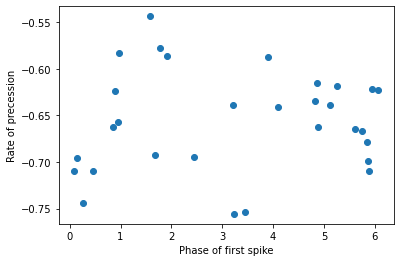

In [30]:
def multiple_sims(num_sims):
    first_spk_phases = []
    phase_prec_rates = []

    for i in range(num_sims):
        print(f"Simulation Number {i}")
        results = run_single_sim()
        times,phases = results['spike_times'], results['spike_phases']

        pp_rate = phase_prec_rate(times,phases)

        first_spk_phases.append(phases[0])
        phase_prec_rates.append(pp_rate)


    results = {'FirstSpikePhase':first_spk_phases,
               'PhasePrecRate':phase_prec_rates}
    
    return results
    

sample_res = multiple_sims(30)

print(sample_res)

first_spk_phases = sample_res['FirstSpikePhase']
phase_prec_rates = sample_res['PhasePrecRate']

plt.scatter(first_spk_phases,phase_prec_rates)
plt.xlabel("Phase of first spike")
plt.ylabel("Rate of precession")

plt.show()